## ECON4060H 2021 Winter
## Quantitative Methods in Economics
### Week 8/9 Structural Estimation: SMM
### Shutao Cao

## 1. Model: consumption over the life cycle
### A simple consumption-saving model in finite horizon
A household leaves for $T$ periods, earnings at age $t$ is $y_t$. The household leaves no bequest at the end of life. The Bellman equation is 

\begin{align*}
            & \quad V(y_t,a_t) = \max_{\{c_t,k_{t+1}\}} \big[u(c) + \beta \mathbb{E}_t V(y_{t+1},a_{t+1})\big] \\
            & \quad  \text{s.t.} \\
            & \quad  c_t + a_{t+1} \le y_t + (1+r_t)a_t. \\
            & \quad  a_{t+1}\ge 0, a_0=0, a_{T+1}=0.
\end{align*}

Utility function is $u(c) = \frac{c^{1-\gamma}}{1-\gamma}$.

### Income process
We assume that income is given by
$$\ln (y_t) = \alpha_0 + \alpha_1 t + \alpha_2 t^2 + \eta_t.$$ 

$\eta_t$ is the income shock, it follows an AR(1) process (AR for autoregressive) 
$$\eta_t = \rho \eta_{t-1} + \varepsilon_t,$$ where $\varepsilon_t \sim N(0,\sigma_{\varepsilon}^2)$.

## 2. Solving the Model

We set the risk aversion coefficient as $\gamma = 2.5$.

### Income process
We use backward induction to solve for the solution. First, we set some parameter values. The income process is set as
$$ \ln (y_t) =  0.5 + 0.09 \cdot t -0.00085 \cdot t^2$$ for $t = 20, 21, \cdots, 74$.

For income shock process, we set $\rho=0.63$ and $\sigma=0.042$. We discretize the AR(1) process following the method Ada and Cooper (2003). We use the subroutine written in Fortran 90 by Shutao Cao. We set the income state size to be $n_{\eta} = 5$.

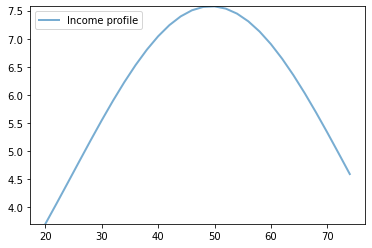

In [2]:
import numpy as np
import matplotlib.pyplot as plt
ageGrid = np.array(np.linspace(20, 74, 28, dtype=int))
#yincome =  np.exp(0.5 + 0.082 *ageGrid -0.00083 * ageGrid**2)
yincome =  np.exp(0.0 + 0.082 *ageGrid -0.00083 * ageGrid**2)
fig, ax = plt.subplots()
ax.set_ylim(np.min(yincome), np.max(yincome))
ax.plot(ageGrid, yincome, lw=2, alpha=0.6, label='Income profile')
ax.legend()
plt.show()


In [3]:
#--income shock process
from scipy import linalg
import markovAR1
print(markovAR1.__doc__)
#e_t = mu*(1-rho) + rho*e_{t-1} + u_t, u_t ~ N(0, sigmau)
# cooper (rho, sigmau, mu, esize, sprd, e, tran)
n=4
rho, sigma_epsilon = 0.63, 0.042
shockmean = 0.0
shockGridtmp, shockTrans = markovAR1.cooper(rho,sigma_epsilon,shockmean,n,2.2)
shockGrid = np.exp(shockGridtmp)
print('shockGrid=', shockGrid)
print('shockTrans=', shockTrans)
# the invariant distribution of income shock is
shockDistr = markovAR1.invdistfun(shockTrans)
print('shock distribution', shockDistr)

This module 'markovAR1' is auto-generated with f2py (version:2).
Functions:
  e,tran = cooper(rho,sigmau,mu,esize,sprd)
  invdist = invdistfun(trans,n=shape(trans,0))
  result,ccum = cumnormal(arg)
  bhat,stderr_bhat,rsq,rsq_adj = ols(x,y,n=shape(x,0),k=shape(x,1))
.
shockGrid= [0.88782474 0.94224452 1.         1.06129563 1.12634842]
shockTrans= [[3.66948795e-01 4.92198013e-01 1.34518563e-01 6.28836109e-03
  4.62680050e-05]
 [1.08918083e-01 4.64128978e-01 3.72217575e-01 5.34589824e-02
  1.27638136e-03]
 [1.68075297e-02 2.22596876e-01 5.21191188e-01 2.22596876e-01
  1.68075297e-02]
 [1.27638136e-03 5.34589824e-02 3.72217575e-01 4.64128978e-01
  1.08918083e-01]
 [4.62680050e-05 6.28836109e-03 1.34518563e-01 4.92198013e-01
  3.66948795e-01]]
shock distribution [0.0531307  0.24302172 0.40769517 0.24302172 0.0531307 ]


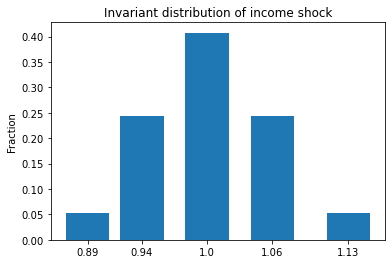

In [4]:
shockGrid2 = np.round(shockGrid,2)
fig, ax = plt.subplots()
ax.bar(shockGrid2, shockDistr, 0.04)
ax.set_ylabel('Fraction')
ax.set_title('Invariant distribution of income shock')
ax.set_xticks(shockGrid2)
ax.set_xticklabels(shockGrid2)
#ax.tick_params(axis='x', labelsize=12)
#ax.legend()
plt.show()

### Implementing value function with backward induction

There are two state variables: asset $a_t$ and income shock $\eta_t$.

The algorithm starts from the last period $T$, solving for optimal consumption given all possible values of state variables at $T$. Then the algorithm goes to age $T-1$, continues until age $1$.

We adapt some utilities from quantecon.org

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
%matplotlib inline

#### State-action value function
The class, defined below, combines both parameters and a method that realizes the right hand side of the Bellman equation.

In [6]:
class LifeCycleModel:
    def __init__(self,
                 u,            # utility function
                 shockGrid,    # shockGrid
                 shockTrans,   # shock transition matrix
                 yincome,      # age profile of income
                 discFactor=0.98*0.98,    # discount factor
                 intrate = 0.08,   # interest rate
                 grid_max=480.0,
                 grid_size=120):
        
        self.u, self.shockGrid, self.shockTrans, self.discFactor,self.yincome = u, shockGrid, shockTrans, discFactor,yincome
        self.grid_max = grid_max
        self.intrate = intrate
        
        # Set up grid of assets
        aGrid1 = np.linspace(-5.0, grid_max*0.3, 90)
        aGrid2 = np.linspace(aGrid1[-1]*1.05, grid_max, 30)
        self.aGrid = np.append(aGrid1,aGrid2)
        
    def state_action_value(self, c, tmpx):
        """
        Right hand side of the Bellman equation, for each current state (age, a,eta).
        """
        v_array = tmpx[0]
        statei = tmpx[1]
        shocki, agridi, agei = statei
        u, discFactor, shockGrid, shockTrans,yincome = self.u, self.discFactor, self.shockGrid, self.shockTrans,self.yincome
        aGrid = self.aGrid
        intrate = self.intrate

        y = yincome[agei]*shockGrid[shocki]

        vvalue = np.zeros(len(shockGrid))

        for j in range(len(shockGrid)):

            v = interp1d(aGrid, v_array[j,:], kind='linear',fill_value='extrapolate')

            aprime = y+ (1.0+intrate)*aGrid[agridi] - c

            vvalue[j] = v(aprime)

        vmean = shockTrans[shocki,:]@vvalue

        vreturn = u(c) + discFactor * vmean

        return -vreturn

In the state-action value function, we have used the one-dimension of linear interpolation to obtain the future value function for state $a_{t+1}$ that is off grid of $a$.

At each age $t$ and for each current state (`shock_i`, `agrid_i`), we compute the expected future value function `vmean`, which is
$$E V_{t+1} = \sum_{j=1}^n Prob(\eta_j | \eta_i) \cdot V(t+1,\eta_j,a')$$ where $a'$ is to be chosen. 

#### The Bellman Operator

The next function implements the Bellman operator.

In [7]:
# solve for bellman equation
def T(og,ageGrid):
    """
    The Bellman operator.  Updates the guess of the value function
    and also computes consumption policy.
      * og is an instance of OptimalGrowthModel
      * v is an array representing a guess of the value function
    """
    # create value function array to fill in with optimal values
    v = np.zeros([len(ageGrid),len(og.shockGrid),len(og.aGrid)])
    c = np.zeros([len(ageGrid),len(og.shockGrid),len(og.aGrid)])
    # The last period
    for shocki in range(len(og.shockGrid)):
        for agridi in range(len(aGrid)):
            c[-1,shocki,agridi] = og.yincome[-1]*og.shockGrid[shocki] + (1.0+og.intrate) * og.aGrid[agridi]
            v[-1,shocki,agridi] = og.u(c[-1,shocki,agridi])
    # start from the second from the last age (73)
    agelist = list(range(len(ageGrid)))
    for agei in agelist[-2::-1]:
        v_future=v[agei+1,:,:]
        print('start age',ageGrid[agei])
        for shocki in range(len(shockGrid)):
            for agridi in range(len(og.aGrid)):
                statei=[shocki,agridi,agei]
                tmpx = (v_future,statei)
                # Maximize RHS of Bellman equation at state y
                #c_star, v_max = maximize(og.state_action_value, 1e-10, og.grid_max+yincome[agei]*shockGrid[-1], (v_array, statei))
                res = minimize_scalar(og.state_action_value, bounds=(1.0e-10,aGrid[-1]),args=(tmpx,), method='bounded')
                v[agei,shocki,agridi] = -res.fun
                c[agei,shocki,agridi] = res.x
    return c,v

Next, create an instance of the model with the above primitives and assign it to the variable `og`.

In [8]:
# utility function
gammax = 2.5
def utilityFun(c):
    if c>0:
        if np.abs(c-1.0)<0.000001:
            return np.log(c)
        else:
            return (c**(1.0-gammax)-1.0) / (1.0-gammax)
    else:
        return -5.0e20

#### Run the code

In [9]:
# create an instance
og = LifeCycleModel(u=utilityFun, shockGrid=shockGrid, shockTrans=shockTrans, yincome=yincome)
aGrid=og.aGrid
intrate=og.intrate

# Now solve the model with backward induction
c_opt, v_opt = T(og,ageGrid)

start age 72
start age 70
start age 68
start age 66
start age 64
start age 62
start age 60
start age 58
start age 56
start age 54
start age 52
start age 50
start age 48
start age 46
start age 44
start age 42
start age 40
start age 38
start age 36
start age 34
start age 32
start age 30
start age 28
start age 26
start age 24
start age 22
start age 20


#### Plot value function and consumption function

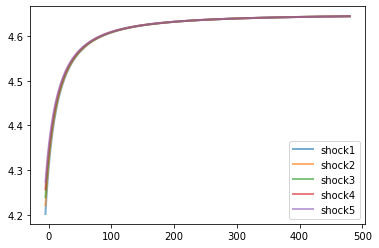

In [10]:
fig, ax = plt.subplots()
agei=20 # age ageGrid[agei]
ax.plot(aGrid, v_opt[agei,0,:], lw=2, alpha=0.6,label='shock1')
ax.plot(aGrid, v_opt[agei,1,:], lw=2, alpha=0.6,label='shock2')
ax.plot(aGrid, v_opt[agei,2,:], lw=2, alpha=0.6,label='shock3')
ax.plot(aGrid, v_opt[agei,3,:], lw=2, alpha=0.6,label='shock4')
ax.plot(aGrid, v_opt[agei,4,:], lw=2, alpha=0.6,label='shock5')

ax.legend()
#ax.set_ylim(-35, -24)
plt.show()

The figure shows that we are pretty much on the money.

#### The optimal consumption
The policy `c_opt` computed above corresponds to an approximate optimal policy.

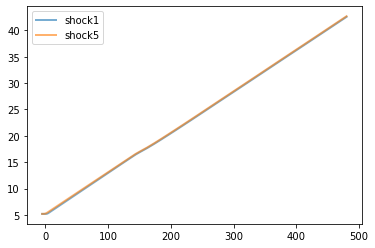

In [11]:
# consumption
fig, ax = plt.subplots()
agei=0
ax.plot(aGrid, c_opt[agei,0,:], lw=2, alpha=0.6,label='shock1')
#ax.plot(aGrid, c_opt[agei,1,:], lw=2, alpha=0.6,label='shock2')
#ax.plot(aGrid, c_opt[agei,2,:], lw=2, alpha=0.6,label='shock3')
#ax.plot(aGrid, c_opt[agei,3,:], lw=2, alpha=0.6,label='shock4')
ax.plot(aGrid, c_opt[agei,4,:], lw=2, alpha=0.6,label='shock5')

ax.legend()
#ax.set_ylim(-35, -24)
plt.show()


The figure shows that we’ve done a good job in this instance of approximating
the true policy.

### Simulate the household's life cycle

We can simulate a panel of households, obtaining the consumption and asset over the life cycle for each simulated household.

First, we generate random values from uniform distribution on interval $[0, 1]$

In [12]:
# generate an array of uniform random variates
from numpy.random import default_rng
nsim = 30 # number of households
nage = len(ageGrid)
rng = default_rng(54321)
sampleUnif = rng.uniform(0,1,nsim*nage)
sampleUnif = np.reshape(sampleUnif,(nage,nsim), order='F')

Second, we simulate the income shock process for each household. 

In [13]:
#---Simulate the the life cycle for 500 households and calculte moments
def simulateShocks(nsim,ageGrid,shockGrid,shockTrans,shockDistr,sampleUnif):
    typeCDF = np.cumsum(shockDistr)
    shockCDF = np.cumsum(shockTrans,axis=1)    # convert into cummulative conditional distribution
    
    # create the simulated shocks of nsim households
    simulShockHH = np.zeros((nage,nsim),dtype=int)
    
    # state id
    state = list(range(len(shockGrid)))
    nstate = len(state)
    
    # Start simulating income shock process
    for i in range(nsim):
        # initial state at birth
        for statei in state:
            if sampleUnif[0,i] <= typeCDF[statei]:
                simulShockHH[0,i] = statei
                break
        # since age 2
        for agej in range(1,nage,1):
            for statei in state:
                if sampleUnif[agej,i] <= shockCDF[simulShockHH[agej-1,i],statei]:
                    simulShockHH[agej,i] = statei
                    break
    
    # stat to simulate the life-cycle decisions
    # initial asset can be zero or picked from aGrid[2]= 0.1685
    simulAssetHH = np.zeros((nage,nsim))
    simulConsuHH = np.zeros((nage,nsim))
    for i in range(nsim):
        # initial state of asset
        simulAssetHH[0,i] = aGrid[2]
        # asset and consumption since age 1
        for agej in range(0,nage-1,1):
            shockj = simulShockHH[agej,i]
            v = interp1d(aGrid, c_opt[agej,shockj,:], kind='linear',fill_value='extrapolate')
            simulConsuHH[agej,i] = v(simulAssetHH[agej,i],)
            simulAssetHH[agej+1,i] = yincome[agej]*shockGrid[shockj]+(1.0+intrate)*simulAssetHH[agej,i] - simulConsuHH[agej,i]
        # consumption in the las period
        shockj = simulShockHH[nage-1,i]
        simulConsuHH[-1,i] = yincome[-1]*shockGrid[shockj]  + (1.0+intrate)*simulAssetHH[-1,i]
    return simulConsuHH, simulAssetHH

Third, we calculate moments using the simulated household data.

Below, we calculate the mean value of serial correlation coefficients

In [16]:
# calculate moments
# serial correlation of consumption
import pandas as pd
simulConsuHH, simulAssetHH = simulateShocks(nsim,ageGrid,shockGrid,shockTrans,shockDistr,sampleUnif)
csim = pd.DataFrame(simulConsuHH)
csim.index = pd.to_datetime(csim.index)
varnames = list(csim.keys())
current=0
corrauto={}
corrauto0={}
while current < len(varnames):
    corrauto0[varnames[current]] = csim[varnames[current]].autocorr(lag=1)
    corrauto.update(corrauto0)
    current +=1

moment_c = list(corrauto.values())
np.mean(moment_c)

0.9464245501613013

## 3. Estimation the model with SMM

We use the simulated methods of moments (SMM) to estimate the model. As an example, here we only estimate the risk aversion parameter $\gamma$.

First, define the objective function to minimize

In [17]:
def minobjective (gammax):

    # given gammsx value, solve the model
    og = LifeCycleModel(u=utilityFun, shockGrid=shockGrid, shockTrans=shockTrans, yincome=yincome)
    aGrid=og.aGrid
    intrate=og.intrate
    # Now solve the model with backward induction
    c_opt, v_opt = T(og,ageGrid)
    
    # given the model solution, simulate the household and calculate the moment
    simulConsuHH, simulAssetHH = simulateShocks(nsim,ageGrid,shockGrid,shockTrans,shockDistr,sampleUnif)
    csim = pd.DataFrame(simulConsuHH)
    csim.index = pd.to_datetime(csim.index)
    varnames = list(csim.keys())
    current=0
    corrauto={}
    corrauto0={}
    while current < len(varnames):
        corrauto0[varnames[current]] = csim[varnames[current]].autocorr(lag=1)
        corrauto.update(corrauto0)
        current +=1
    
    moment_c = list(corrauto.values())
    #np.mean(moment_c)

    # calculate the moment conditions
    return (np.mean(moment_c) - 0.96)**2

Now use scipy mimimize_scalar to find the value of gammax

In [19]:
# CAUTION: THIS IS A SLOW PROCESS.
res = minimize_scalar(minobjective, bounds=(-5.0, 10.0), method='bounded')
gammax = res.x

start age 72
start age 70


KeyboardInterrupt: 